In [ ]:
# Install required libraries
!pip install -q kaggle ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00


In [ ]:
import os

# Create kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy uploaded kaggle.json
!cp kaggle.json /root/.kaggle/

# Permission
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d banuprasadb/visdrone-dataset

Dataset URL: https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset
License(s): GNU Affero General Public License 3.0
100% 2.10G/2.10G [00:27<00:00, 82.3MB/s]



In [ ]:
!unzip -q visdrone-dataset.zip

In [ ]:
import os

print(os.listdir())

['.config', 'visdrone_filtered.yaml', 'VisDrone_Dataset', 'runs', 'visdrone-dataset.zip', 'best.pt', 'sample_data']


In [ ]:
dataset_path = "/content/VisDrone_Dataset"

print(os.listdir(dataset_path))

['visdrone.yaml', 'VisDrone2019-DET-train', 'VisDrone2019-DET-test-challenge', 'VisDrone2019-DET-val', 'VisDrone2019-DET-test-dev']


In [ ]:
import os

dataset_path = "/content/VisDrone_Dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    print(f"\n📂 {folder}")

    if os.path.isdir(folder_path):
        print(os.listdir(folder_path))


📂 visdrone.yaml

📂 VisDrone2019-DET-train
['images', 'labels']

📂 VisDrone2019-DET-test-challenge
['images']

📂 VisDrone2019-DET-val
['images', 'labels']

📂 VisDrone2019-DET-test-dev
['images', 'labels']


In [ ]:
label_path = "/content/VisDrone_Dataset/VisDrone2019-DET-train/labels"

label_files = os.listdir(label_path)

sample_label = label_files[0]

print("Sample file:", sample_label)

with open(os.path.join(label_path, sample_label), "r") as f:
    lines = f.readlines()

for line in lines[:10]:
    print(line)

Sample file: 9999999_00855_d_0000391.txt
3 0.375750 0.766333 0.042500 0.120667

3 0.368500 0.556000 0.028000 0.089333

3 0.376750 0.458667 0.030500 0.072000

3 0.408500 0.372000 0.029000 0.054667

4 0.367250 0.653667 0.040500 0.082000

4 0.491250 0.660000 0.042500 0.102667

4 0.476250 0.543000 0.033500 0.076667

4 0.448000 0.390000 0.027000 0.062667

3 0.356000 0.342667 0.047000 0.060000

3 0.392500 0.312333 0.028000 0.048667



In [ ]:
import os
import shutil

base_path = "/content/VisDrone_Dataset"

new_path = "/content/visdrone_filtered"

os.makedirs(new_path, exist_ok=True)

In [ ]:
allowed_classes = ['1', '2', '3']  # human + group + car

In [ ]:
def filter_labels(split):
    img_path = os.path.join(base_path, split, "images")
    label_path = os.path.join(base_path, split, "labels")

    new_img_path = os.path.join(new_path, split, "images")
    new_label_path = os.path.join(new_path, split, "labels")

    os.makedirs(new_img_path, exist_ok=True)
    os.makedirs(new_label_path, exist_ok=True)

    for file in os.listdir(label_path):
        label_file = os.path.join(label_path, file)

        with open(label_file, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            cls = line.split()[0]

            if cls in allowed_classes:
                new_lines.append(line)

        if len(new_lines) > 0:
            shutil.copy(label_file, new_label_path)

            img_file = file.replace(".txt", ".jpg")

            src_img = os.path.join(img_path, img_file)
            dst_img = os.path.join(new_img_path, img_file)

            if os.path.exists(src_img):
                shutil.copy(src_img, dst_img)

In [ ]:
filter_labels("VisDrone2019-DET-train")
filter_labels("VisDrone2019-DET-val")

In [ ]:
!pip install ultralytics -q

In [ ]:
data_yaml = """
path: /content/visdrone_filtered

train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images

names:
  0: person
  1: people
  2: car
"""

with open("/content/visdrone_filtered.yaml", "w") as f:
    f.write(data_yaml)

print("Fixed YAML created")

Fixed YAML created


In [ ]:
import os

base = "/content/visdrone_filtered"

splits = [
    "VisDrone2019-DET-train",
    "VisDrone2019-DET-val"
]

mapping = {
    "1": "0",  # person
    "2": "1",  # people group
    "3": "2"   # car
}

for split in splits:
    label_dir = os.path.join(base, split, "labels")

    for file in os.listdir(label_dir):
        path = os.path.join(label_dir, file)

        with open(path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()
            cls = parts[0]

            if cls in mapping:
                parts[0] = mapping[cls]
                new_lines.append(" ".join(parts))

        with open(path, "w") as f:
            f.write("\n".join(new_lines))

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/visdrone_filtered.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="visdrone_detection"
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone_filtered.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c9a5cdfa540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
import os

results_path = "/content/runs/detect/visdrone_detection"
print(os.listdir(results_path))

['BoxPR_curve.png', 'train_batch7941.jpg', 'val_batch1_pred.jpg', 'val_batch2_pred.jpg', 'train_batch2.jpg', 'train_batch7940.jpg', 'confusion_matrix.png', 'BoxR_curve.png', 'val_batch2_labels.jpg', 'val_batch1_labels.jpg', 'BoxF1_curve.png', 'train_batch0.jpg', 'args.yaml', 'train_batch1.jpg', 'val_batch0_pred.jpg', 'results.png', 'weights', 'train_batch7942.jpg', 'confusion_matrix_normalized.png', 'results.csv', 'val_batch0_labels.jpg', 'labels.jpg', 'BoxP_curve.png']


In [ ]:
import os

runs_path = "/content/runs/detect"

print(os.listdir(runs_path))

['val-4', 'val-3', 'val-2', 'visdrone_detection', 'val']


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO

# Load trained model
model = YOLO("/content/best.pt")

# Evaluate model
metrics = model.val(
    data="/content/visdrone_filtered.yaml"
)


RUN: val-4
[]

RUN: val-3
[]

RUN: val-2
[]

RUN: visdrone_detection
['BoxPR_curve.png', 'train_batch7941.jpg', 'val_batch1_pred.jpg', 'val_batch2_pred.jpg', 'train_batch2.jpg', 'train_batch7940.jpg', 'confusion_matrix.png', 'BoxR_curve.png', 'val_batch2_labels.jpg', 'val_batch1_labels.jpg', 'BoxF1_curve.png', 'train_batch0.jpg', 'args.yaml', 'train_batch1.jpg', 'val_batch0_pred.jpg', 'results.png', 'weights', 'train_batch7942.jpg', 'confusion_matrix_normalized.png', 'results.csv', 'val_batch0_labels.jpg', 'labels.jpg', 'BoxP_curve.png']

RUN: val
[]


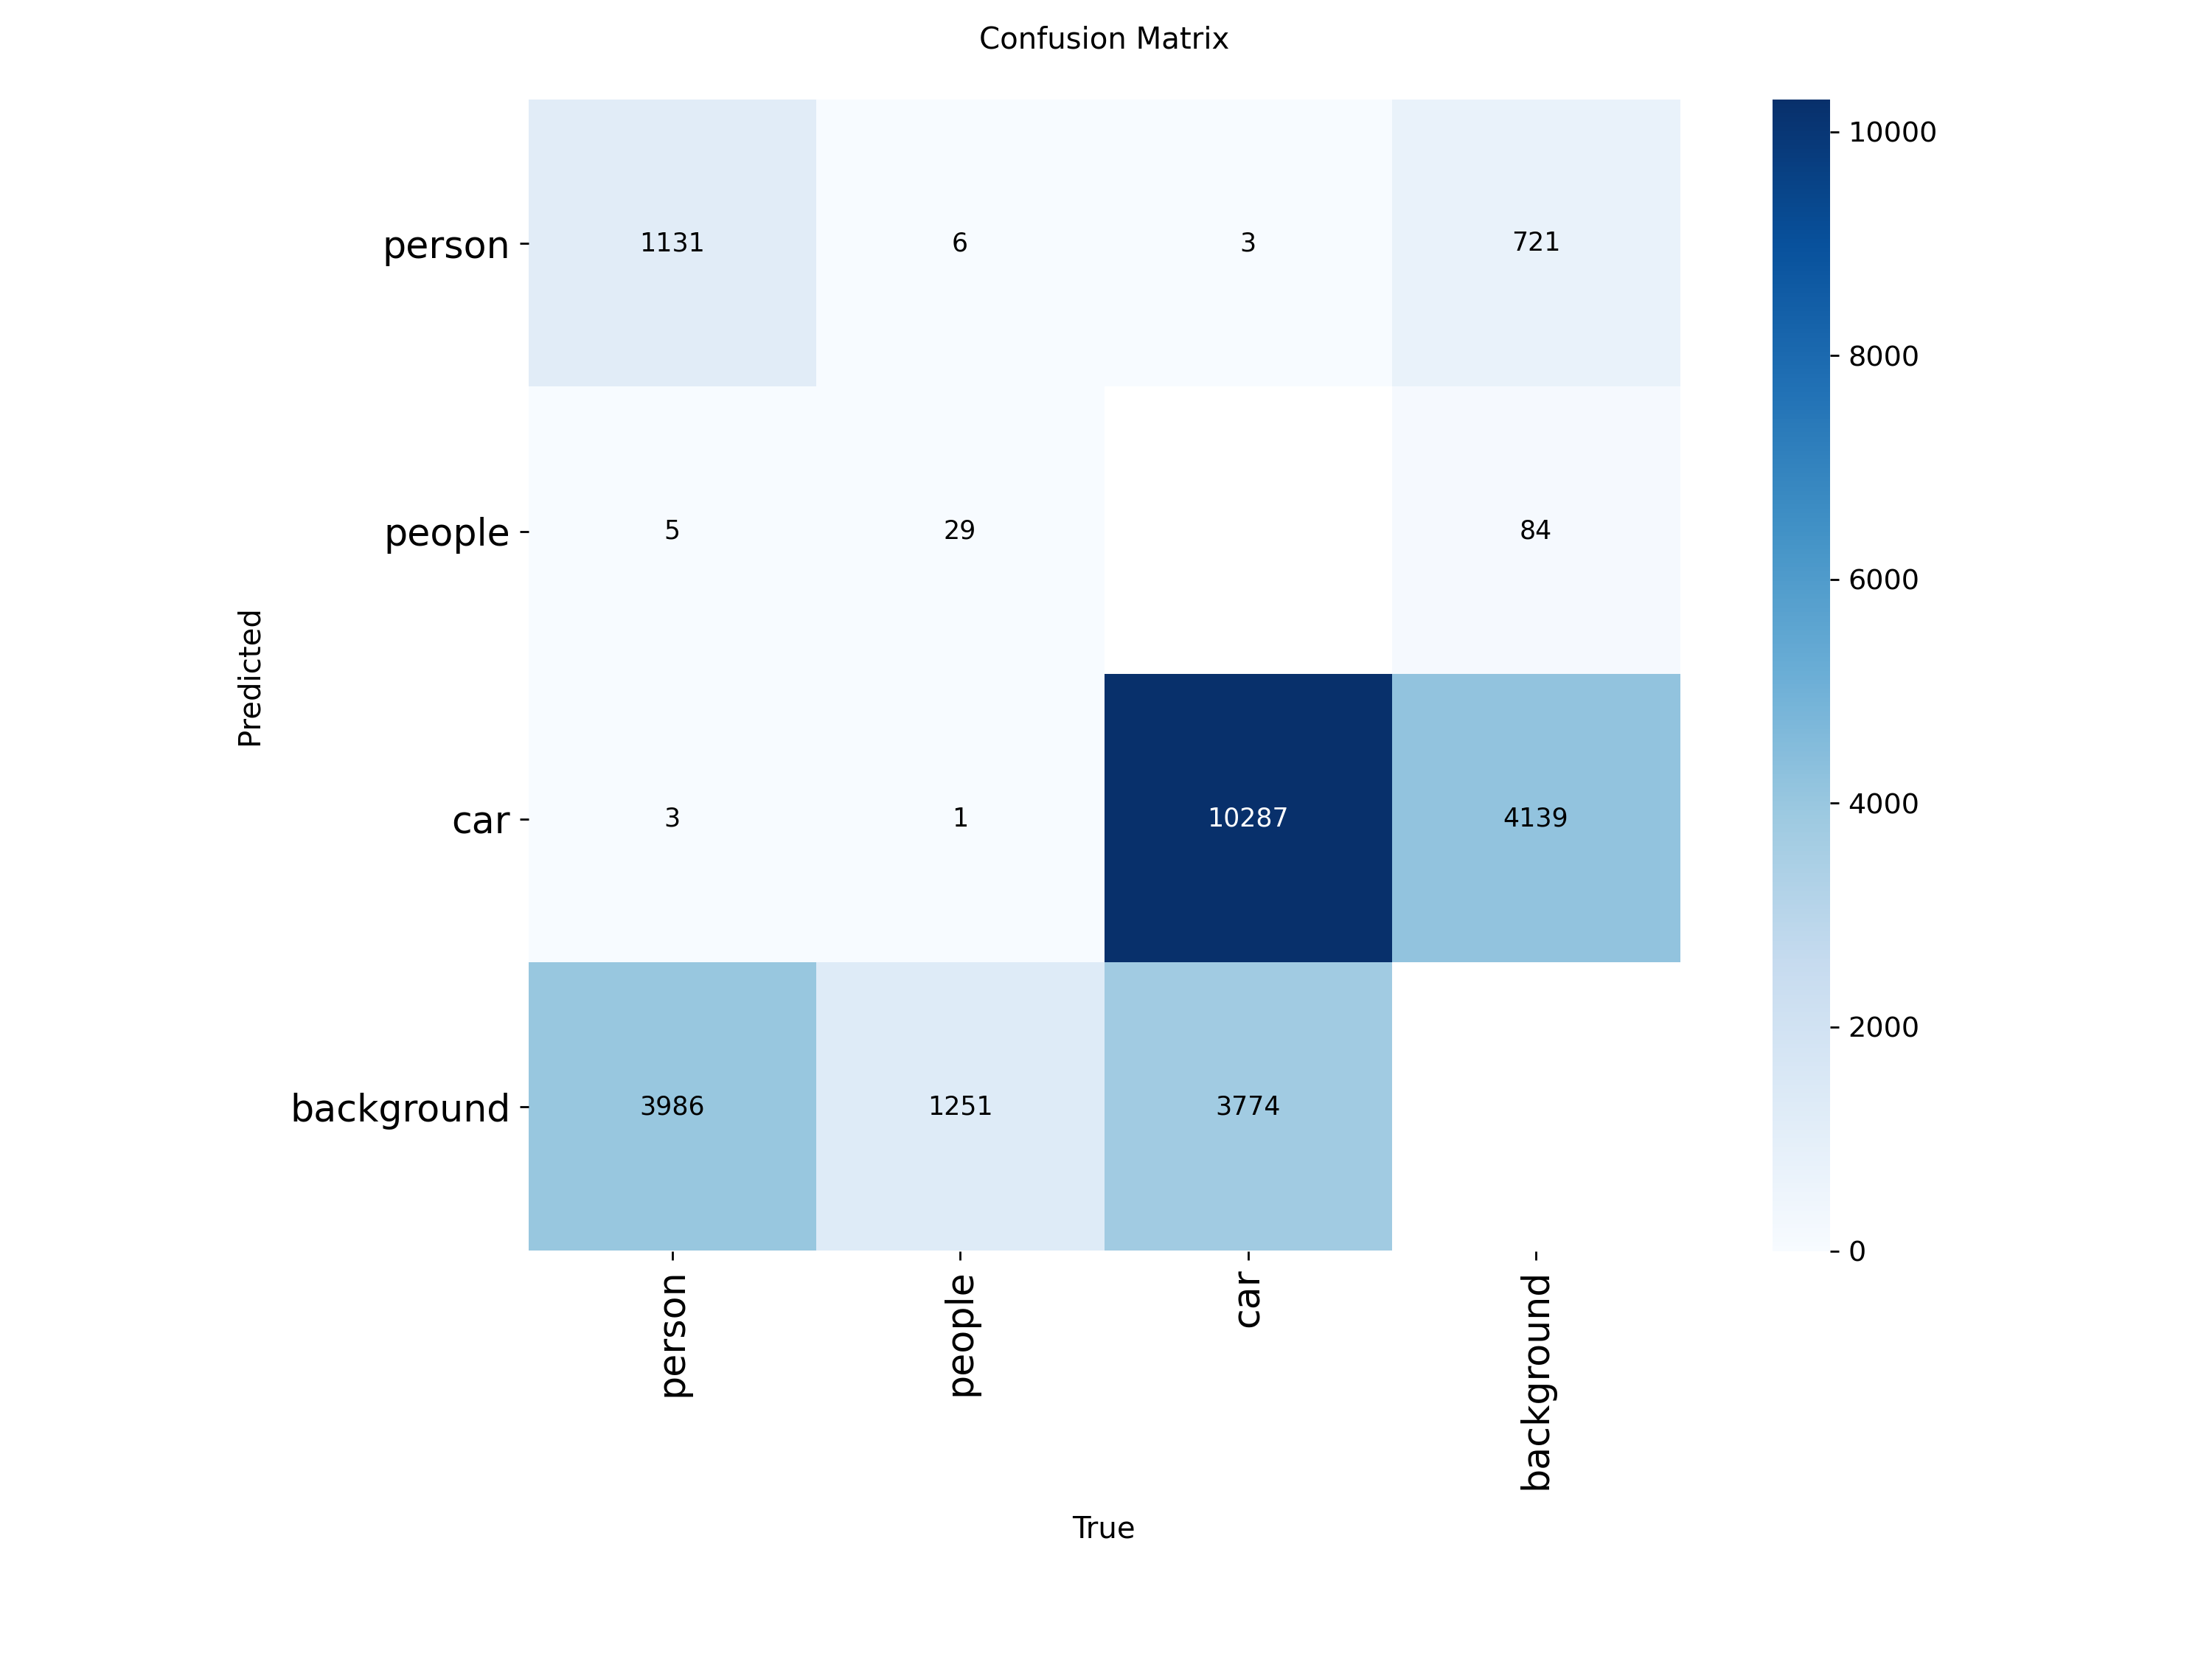

In [ ]:
from IPython.display import Image

Image("/content/runs/detect/visdrone_detection/confusion_matrix.png")

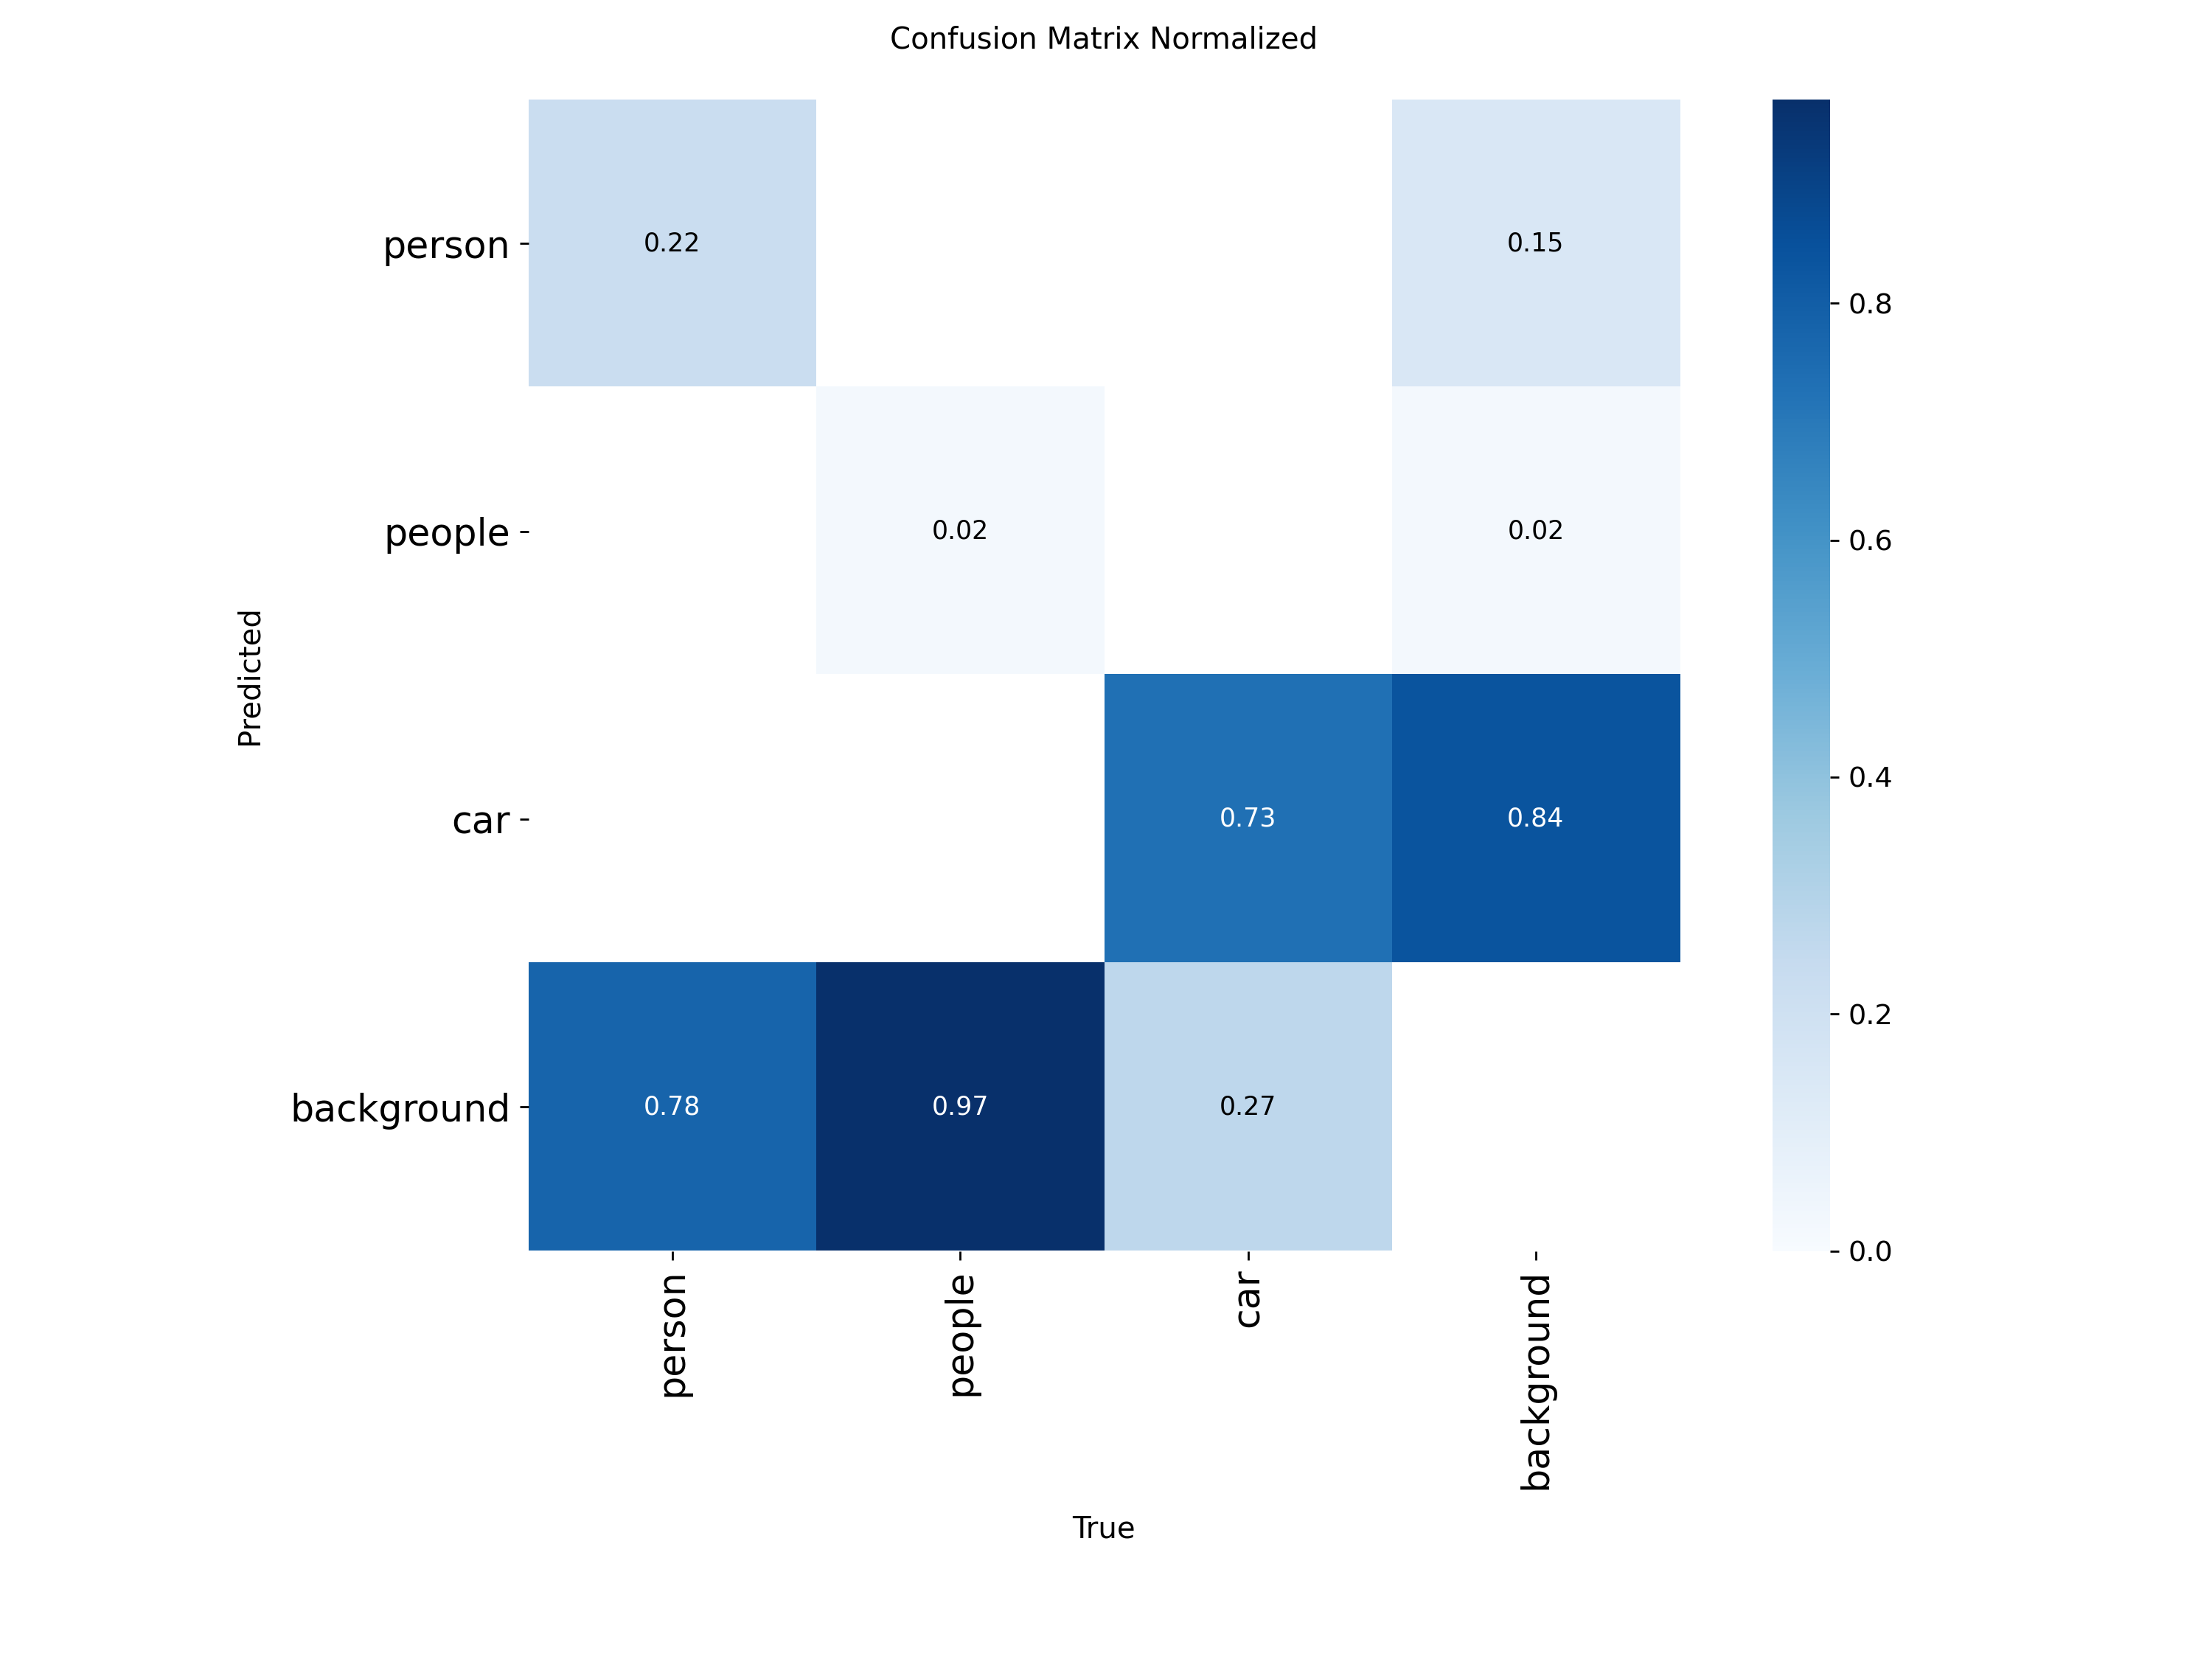

In [ ]:
Image("/content/runs/detect/visdrone_detection/confusion_matrix_normalized.png")

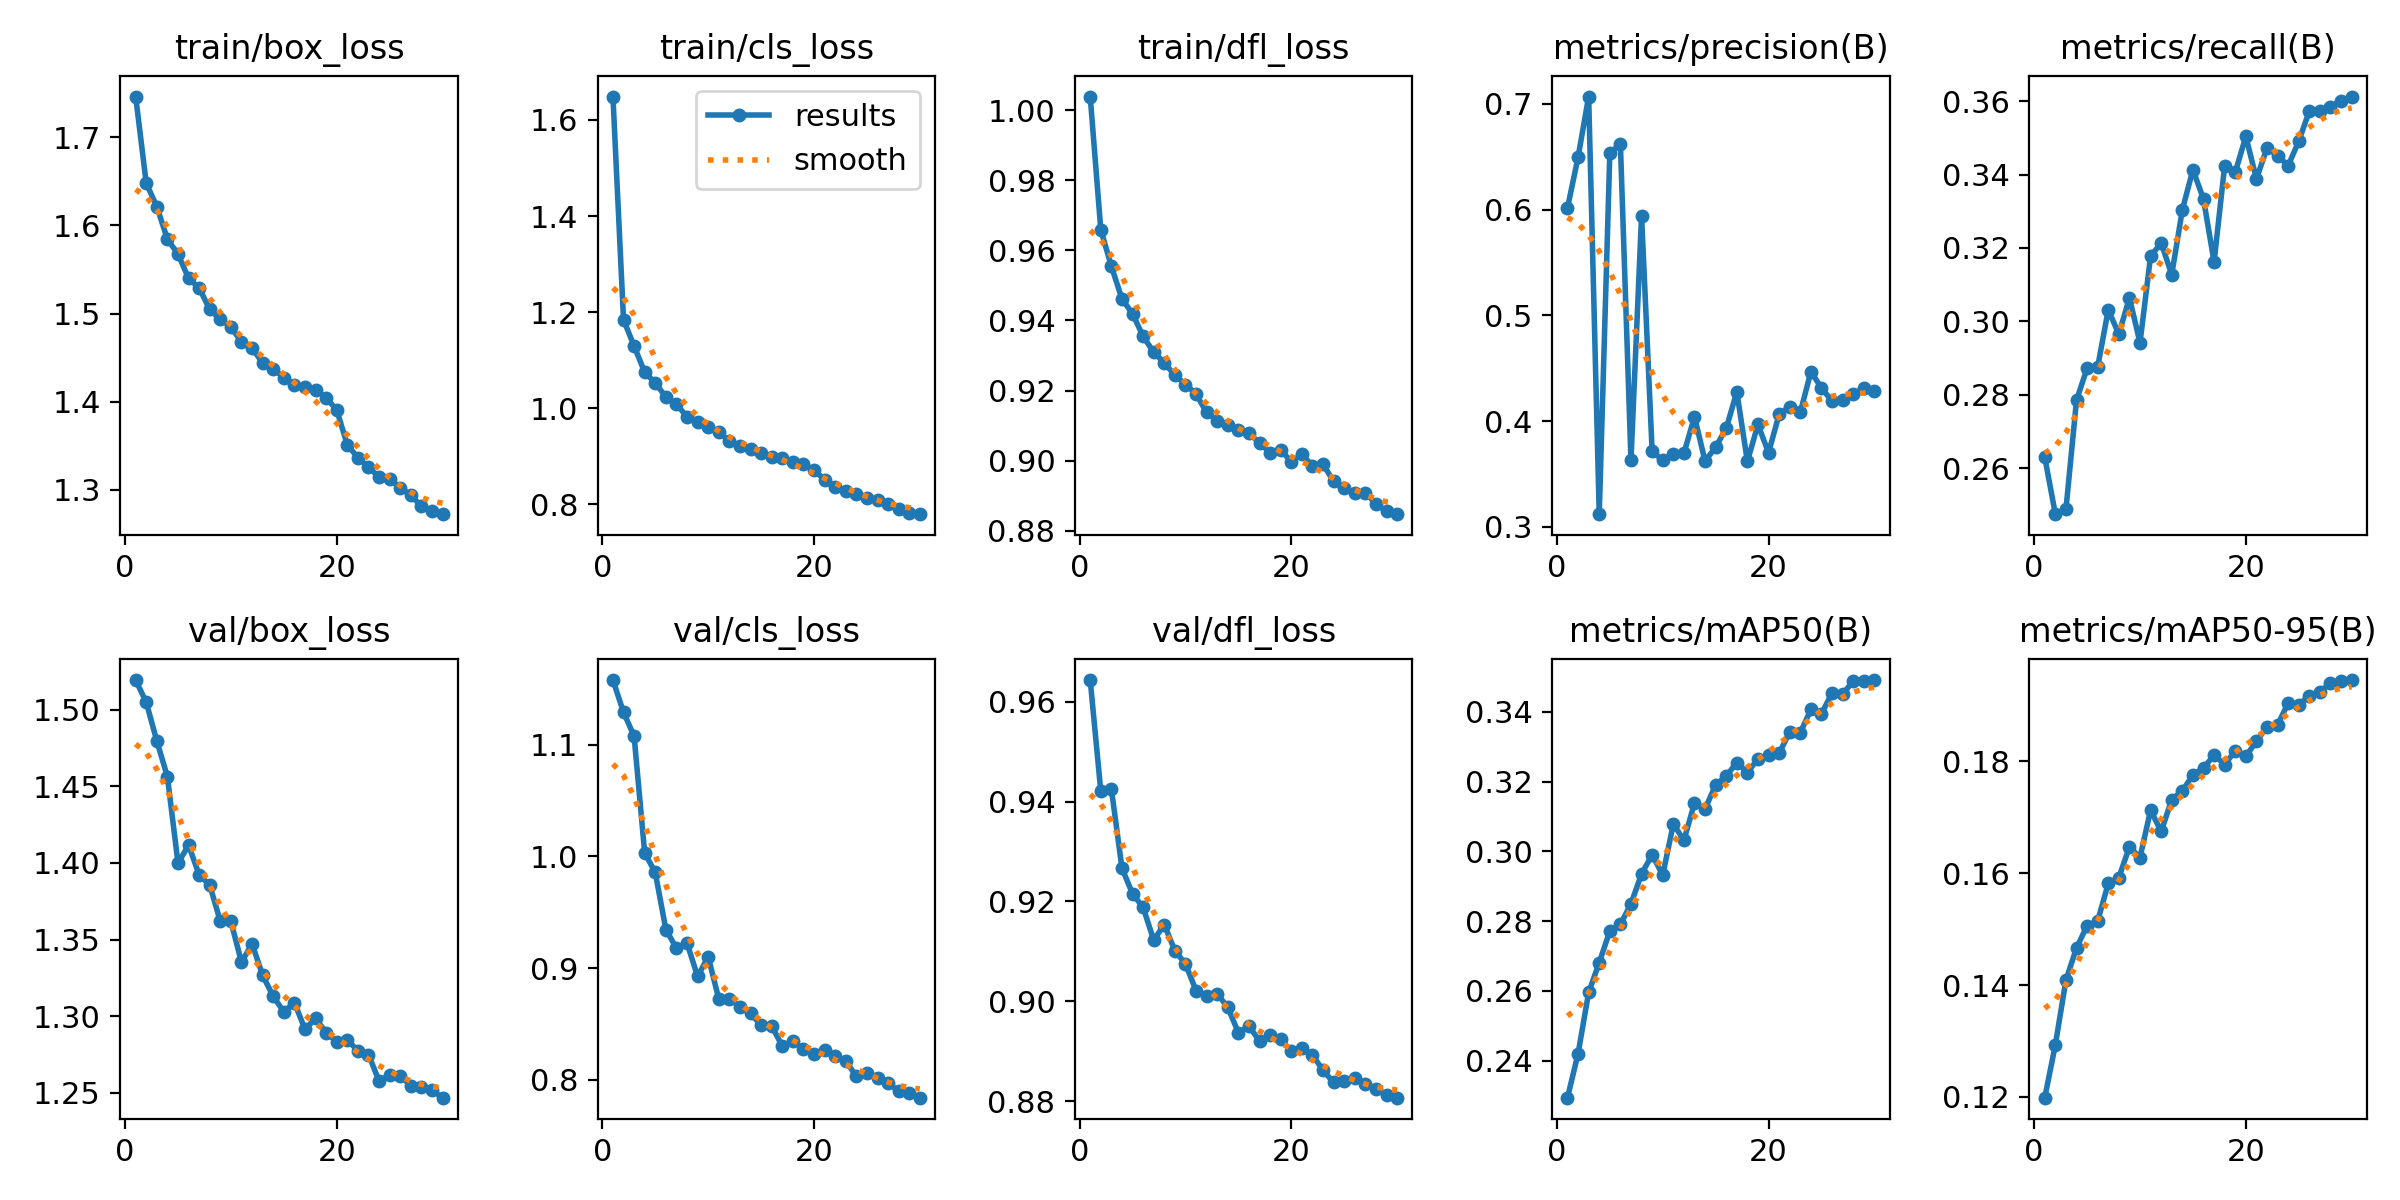

In [ ]:
Image("/content/runs/detect/visdrone_detection/results.png")

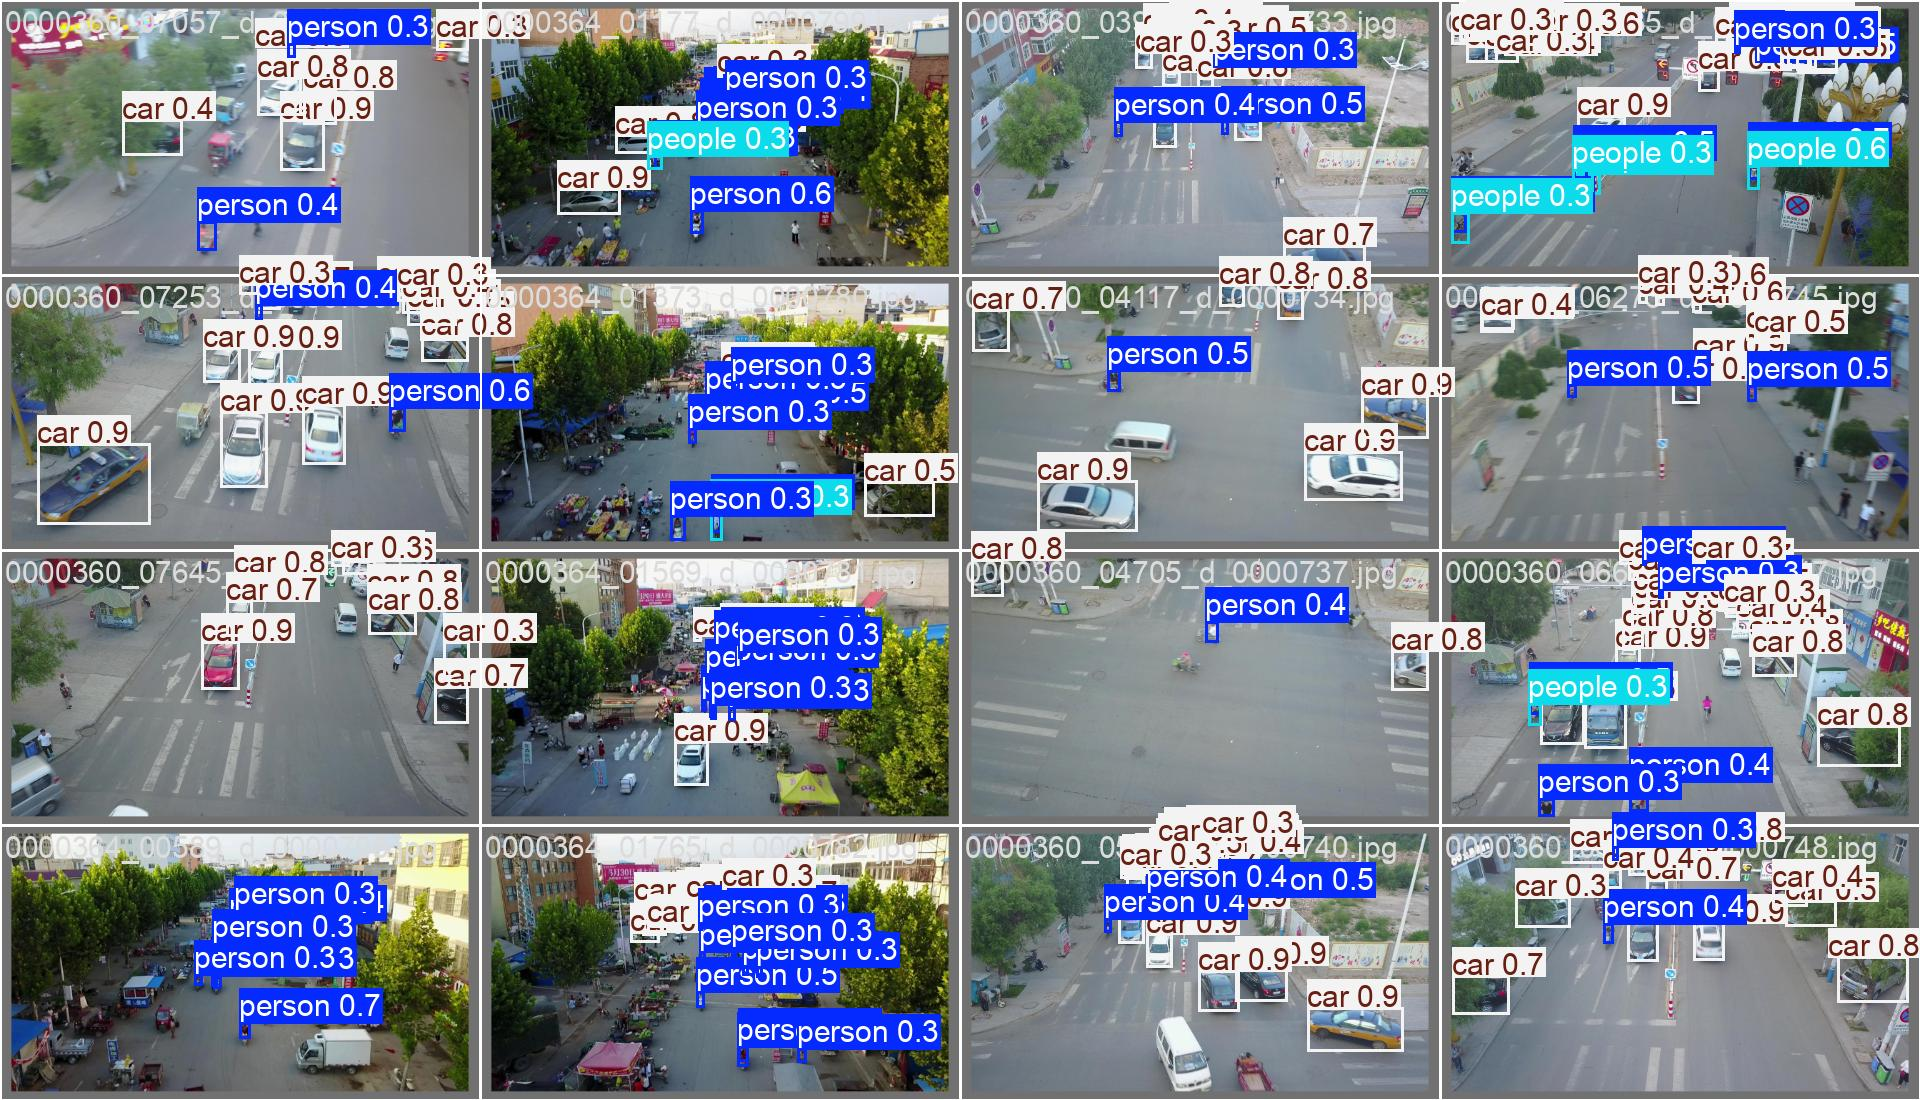

In [ ]:
Image("/content/runs/detect/visdrone_detection/val_batch0_pred.jpg")

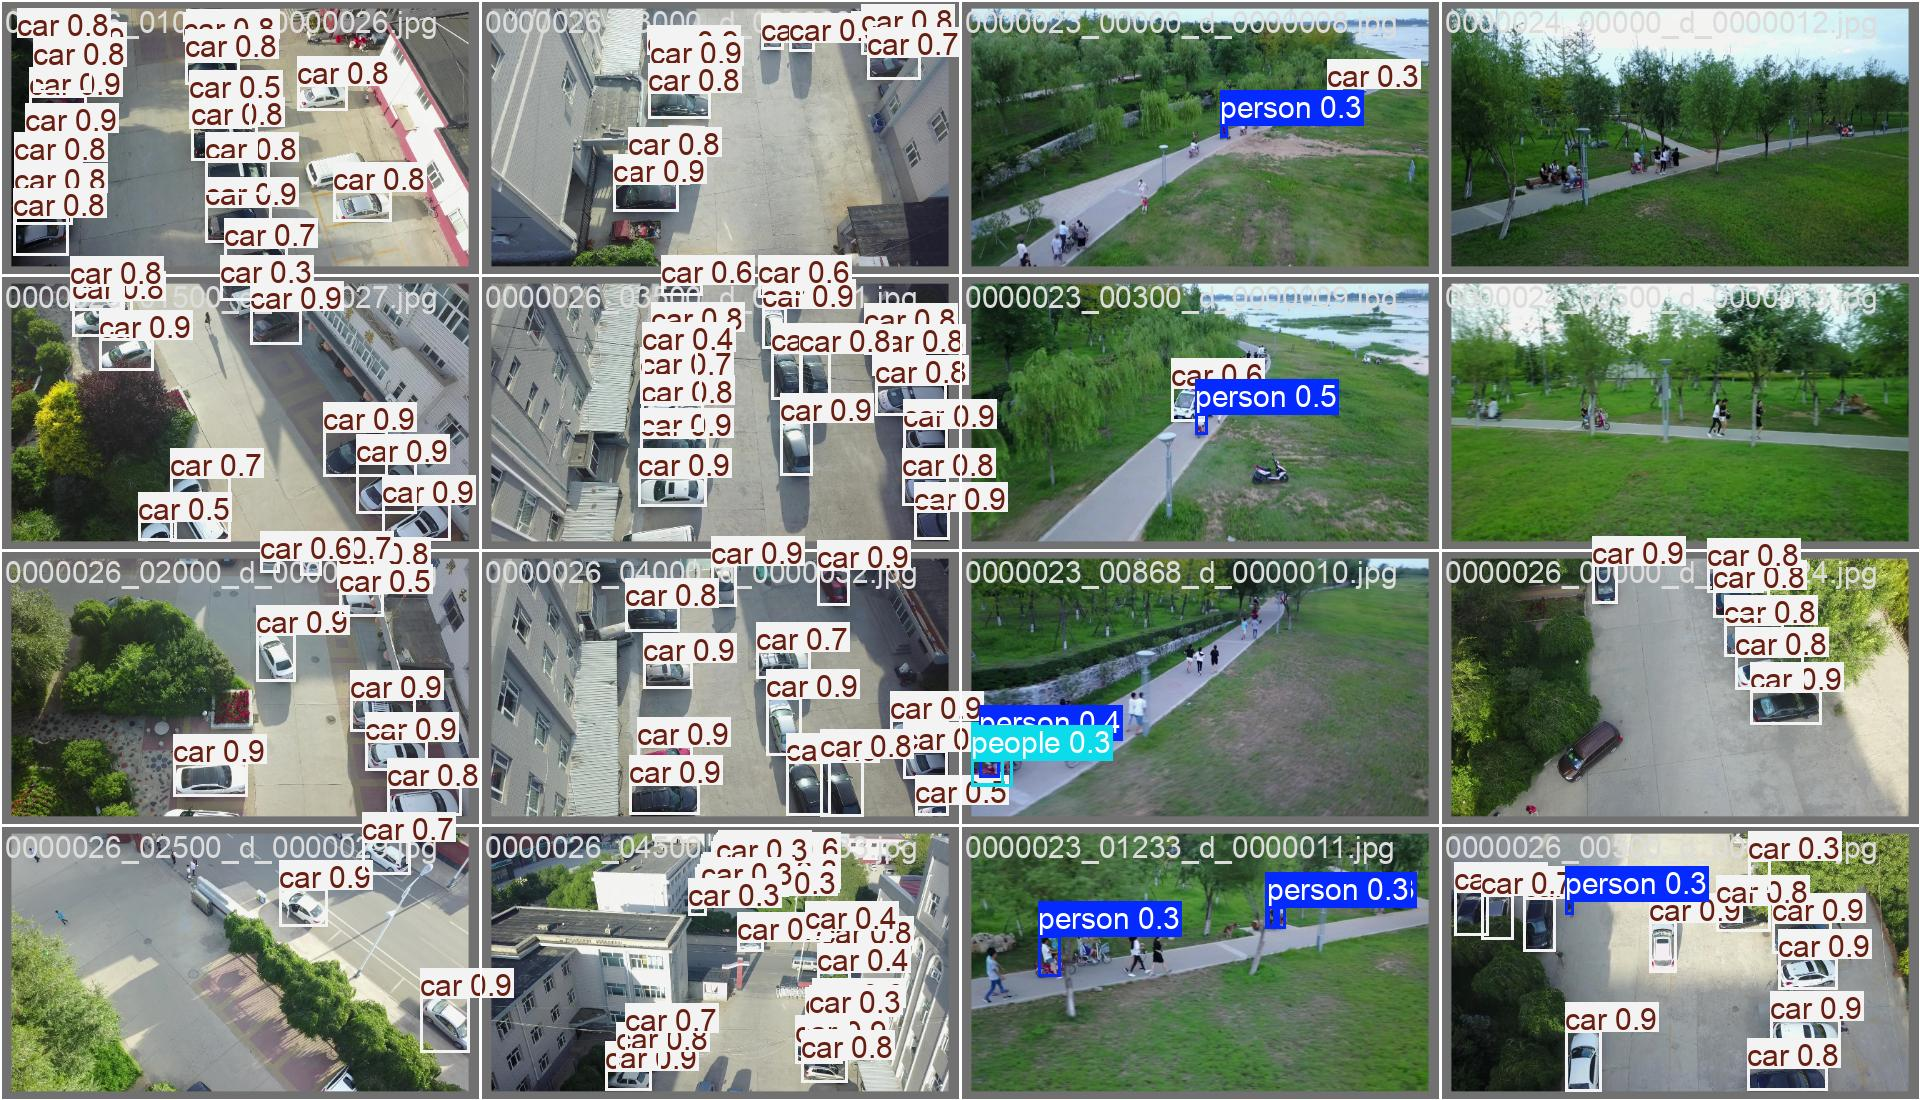

In [ ]:
Image("/content/runs/detect/visdrone_detection/val_batch1_pred.jpg")

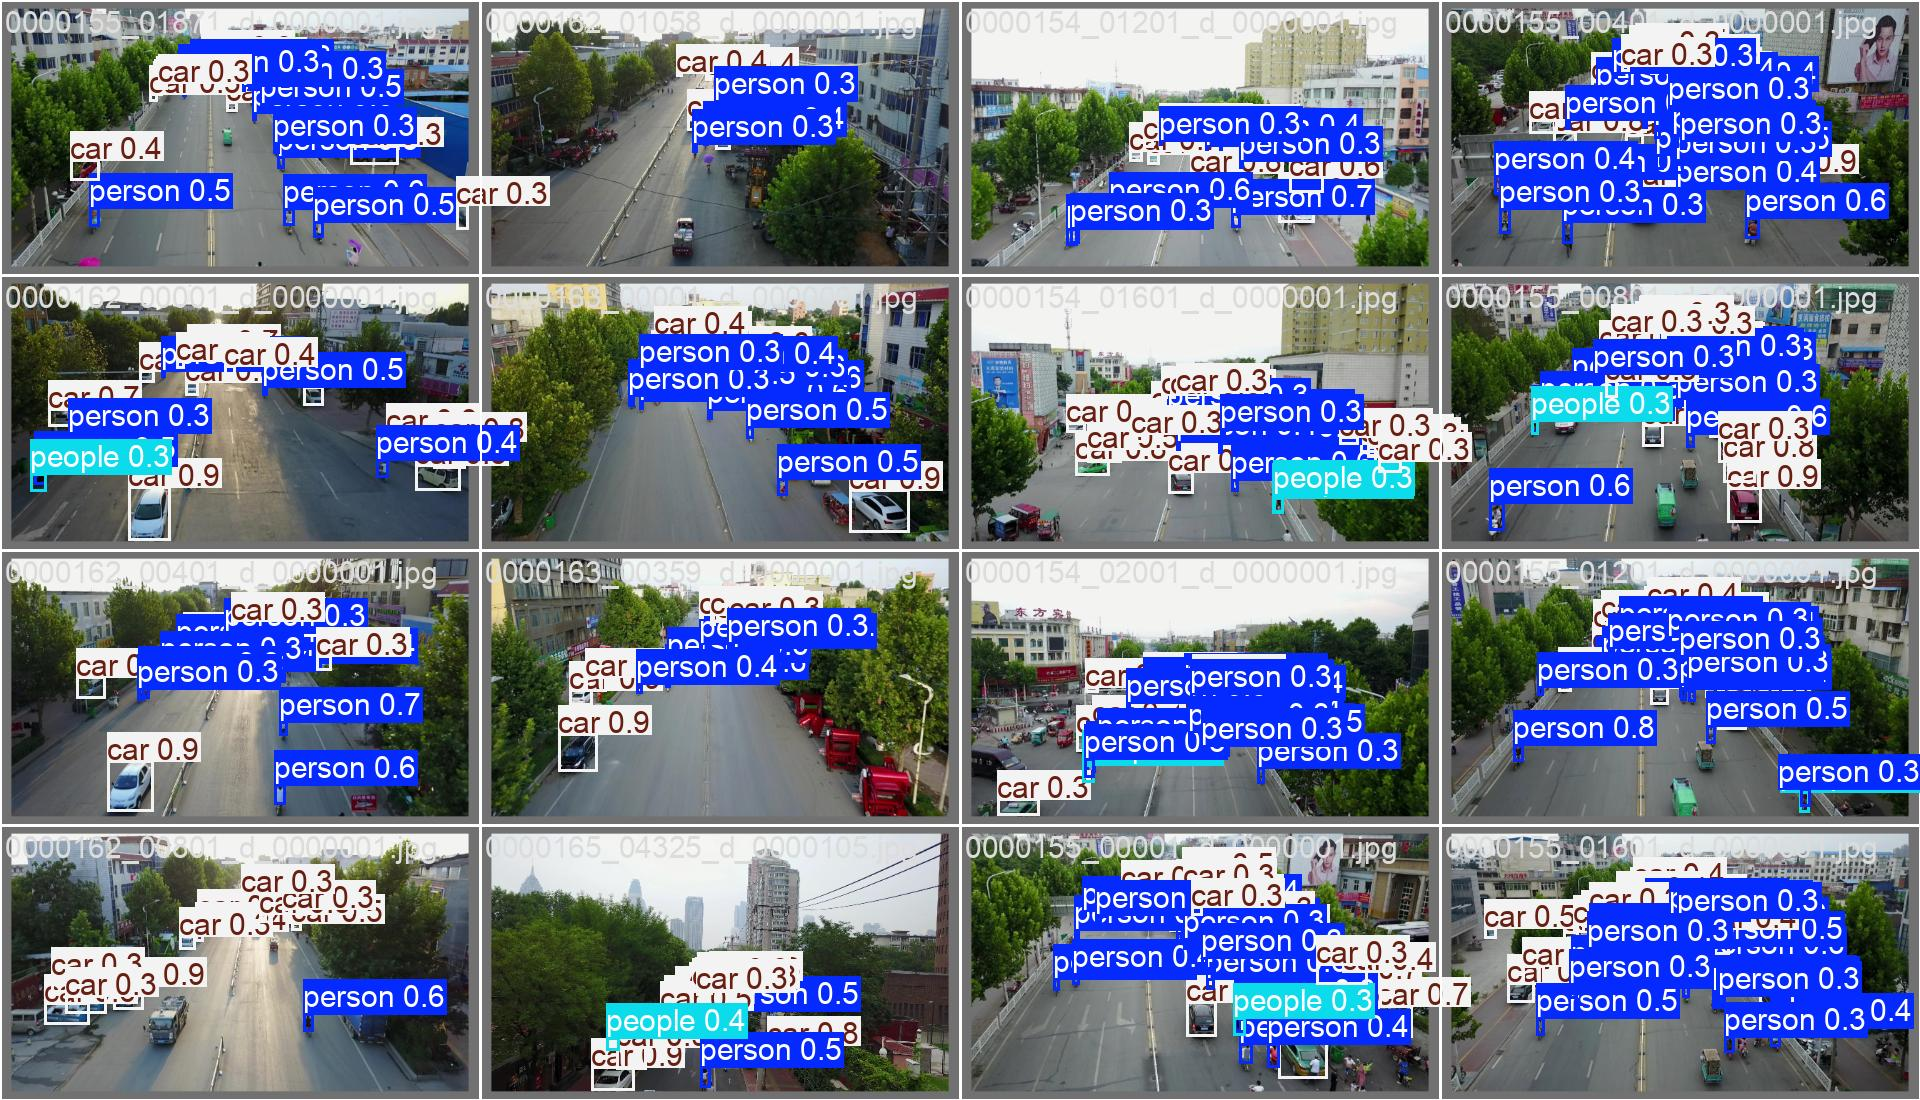

In [ ]:
Image("/content/runs/detect/visdrone_detection/val_batch2_pred.jpg")

In [ ]:
import os

img_dir = "/content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images"

images = os.listdir(img_dir)

print("Total images:", len(images))
print("Sample image:", images[0])

Total images: 1610
Sample image: 9999952_00000_d_0000207.jpg


In [ ]:
img_path = os.path.join(img_dir, images[0])

print("Using image:", img_path)

Using image: /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/9999952_00000_d_0000207.jpg



image 1/1 /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/9999952_00000_d_0000207.jpg: 384x640 15 cars, 41.5ms
Speed: 2.2ms preprocess, 41.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


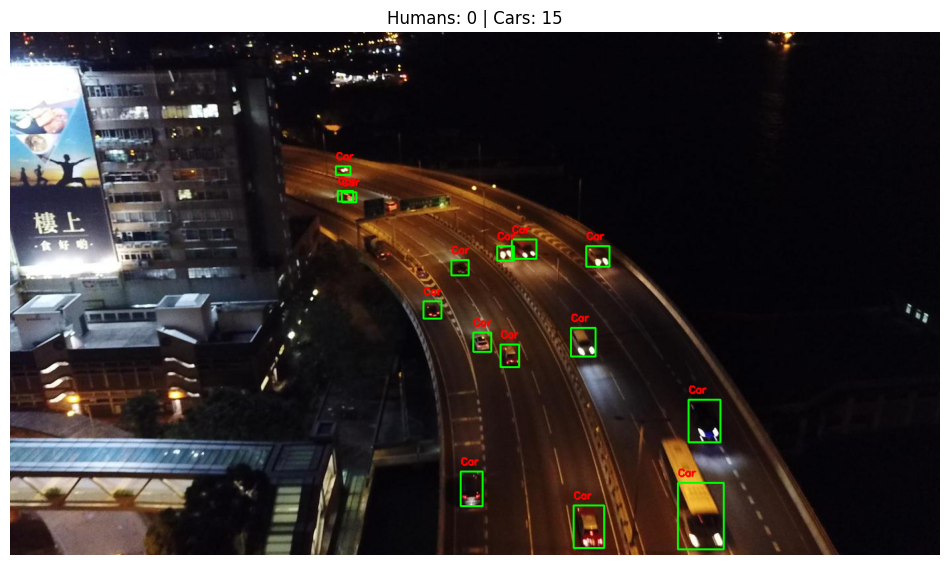

TOTAL HUMANS: 0
TOTAL CARS: 15


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("/content/best.pt")

result = model(img_path)[0]

boxes = result.boxes

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

human_count = 0
car_count = 0

for box in boxes:
    cls = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    if cls in [0, 1]:
        human_count += 1
        label = "Human"
    elif cls == 2:
        car_count += 1
        label = "Car"
    else:
        continue

    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.title(f"Humans: {human_count} | Cars: {car_count}")
plt.show()

print("TOTAL HUMANS:", human_count)
print("TOTAL CARS:", car_count)

In [ ]:
print("===== EVALUATION METRICS =====")

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

print("F1 Score:", metrics.box.f1)

===== EVALUATION METRICS =====
mAP50: 0.34970255210606416
mAP50-95: 0.19551104170040143
Precision: 0.43099470713170934
Recall: 0.3610280823289231
F1 Score: [    0.34367     0.08464     0.67354]


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

test_dir = "/content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images"

results = model.predict(
    source=test_dir,
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1610 /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/0000006_00159_d_0000001.jpg: 384x640 1 person, 39 cars, 7.1ms
image 2/1610 /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/0000006_00611_d_0000002.jpg: 384x640 4 persons, 38 cars, 6.6ms
image 3/1610 /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/0000006_01111_d_0000003.jpg: 384x640 12 cars, 6.2ms
image 4/1610 /content/VisDrone_Dataset/VisDrone2019-DET-test-dev/

['9999952_00000_d_0000207.jpg', '9999952_00000_d_0000285.jpg', '9999976_00000_d_0000029.jpg', '9999938_00000_d_0000083.jpg', '0000120_00559_d_0000092.jpg', '9999938_00000_d_0000286.jpg', '9999938_00000_d_0000221.jpg', '9999938_00000_d_0000404.jpg', '9999938_00000_d_0000274.jpg', '9999952_00000_d_0000079.jpg', '9999938_00000_d_0000019.jpg', '9999963_00000_d_0000018.jpg', '9999973_00000_d_0000104.jpg', '9999952_00000_d_0000328.jpg', '9999938_00000_d_0000395.jpg', '9999941_00000_d_0000027.jpg', '9999938_00000_d_0000480.jpg', '9999963_00000_d_0000042.jpg', '0000347_00511_d_0000048.jpg', '0000183_00216_d_0000177.jpg', '9999952_00000_d_0000195.jpg', '9999938_00000_d_0000324.jpg', '9999986_00000_d_0000041.jpg', '9999938_00000_d_0000076.jpg', '9999973_00000_d_0000123.jpg', '9999938_00000_d_0000448.jpg', '9999973_00000_d_0000056.jpg', '9999938_00000_d_0000106.jpg', '9999938_00000_d_0000459.jpg', '9999947_00000_d_0000020.jpg', '9999986_00000_d_0000009.jpg', '9999952_00000_d_0000171.jpg', '999993

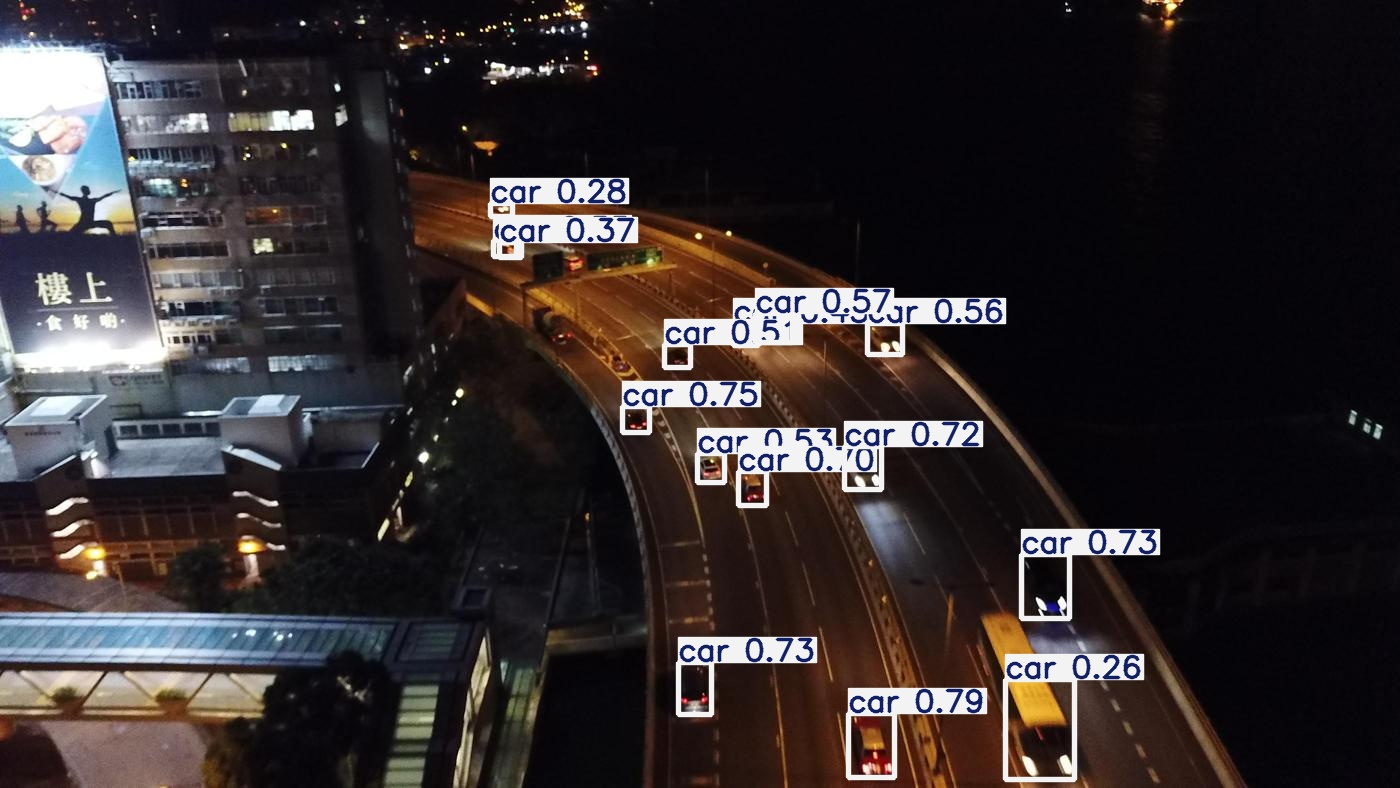

In [ ]:
from IPython.display import Image
import os

pred_dir = "/content/runs/detect/predict"

print(os.listdir(pred_dir))  # see files

Image(os.path.join(pred_dir, os.listdir(pred_dir)[0]))

In [ ]:
metrics = model.val()

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 82.9±44.1 MB/s, size: 120.0 KB)
val: Scanning /content/visdrone_filtered/VisDrone2019-DET-val/labels.cache... 544 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 544/544 163.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.4it/s 10.0s
                   all        544      20476      0.431      0.361       0.35      0.196
                person        482       5125       0.46      0.274      0.267     0.0922
                people        364       1287      0.226     0.0521     0.0453     0.0135
                   car        515      14064      0.607      0.757      0.737      0.481
Speed: 1.0ms preprocess, 2.8ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val-6
